<a href="https://colab.research.google.com/github/OJB-Quantum/LaTeX-to-Nemeth-Braille-to-SVG/blob/main/Nemeth_Braille_Examples_to_SVG_and_DXF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [6]:
!uv pip install --system -q svgwrite gdstk ezdxf matplotlib

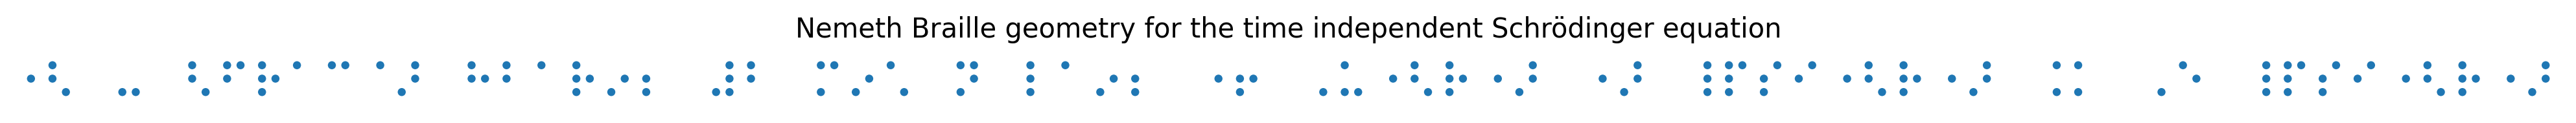

Braille text: ⠐⠣ ⠤ ⠣⠋⠗⠁⠉⠈⠜ ⠓⠃⠁⠗⠔⠆ ⠼⠃ ⠍⠔⠡ ⠝ ⠇⠁⠔⠆ ⠐⠖ ⠠⠥⠐⠣⠗⠐⠜ ⠐⠜ ⠸⠏⠎⠊⠐⠣⠗⠐⠜ ⠨⠅ ⠠⠑ ⠸⠏⠎⠊⠐⠣⠗⠐⠜
Raised dot count: 141
SVG: /content/nemeth_output/schrodinger_nemeth.svg
DXF: /content/nemeth_output/schrodinger_nemeth.dxf
GDS: /content/nemeth_output/schrodinger_nemeth.gds


In [7]:
"""Convert supported LaTeX mathematics into physical Braille dot layouts.

The translation table is explicit and equation specific. Unsupported LaTeX
raises an exception so ambiguous geometry cannot reach the export stage.
"""

from dataclasses import dataclass
from pathlib import Path
import re
from types import MappingProxyType
from typing import Final, Mapping, Sequence, TypeAlias

import ezdxf
from ezdxf import units
import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import svgwrite


Coordinate: TypeAlias = tuple[float, float]
Bounds: TypeAlias = tuple[float, float, float, float]

BRAILLE_MIN: Final = 0x2800
BRAILLE_MAX: Final = 0x28FF
MM_TO_UM: Final = 1_000.0
DXF_LAYER_NAME: Final = "BRAILLE_DOTS"


@dataclass(frozen=True)
class Config:
    """Control knobs for translation, geometry, rendering, and export."""

    dot_radius_mm: float = 0.75
    dot_pitch_x_mm: float = 2.50
    dot_pitch_y_mm: float = 2.50
    cell_pitch_x_mm: float = 6.50
    word_spacing_mm: float = 6.50
    margin_mm: float = 2.00

    preview_size_inches: tuple[float, float] = (16.0, 4.0)

    output_directory: Path = Path("nemeth_output")
    output_stem: str = "schrodinger_nemeth"

    gds_layer: int = 1
    gds_datatype: int = 0
    gds_curve_tolerance_um: float = 0.50
    gds_cell_name: str = "NEMETH_BRAILLE"

    def __post_init__(self) -> None:
        """Validate control knob values."""
        positive_values = (
            self.dot_radius_mm,
            self.dot_pitch_x_mm,
            self.dot_pitch_y_mm,
            self.cell_pitch_x_mm,
            self.word_spacing_mm,
            self.margin_mm,
            self.gds_curve_tolerance_um,
        )

        if any(value <= 0.0 for value in positive_values):
            raise ValueError(
                "Geometry and tolerance values must be positive."
            )

        if self.cell_pitch_x_mm <= self.dot_pitch_x_mm:
            raise ValueError(
                "The cell pitch must exceed the column pitch."
            )

        if self.gds_layer < 0 or self.gds_layer > 65_535:
            raise ValueError(
                "The GDS layer must lie within [0, 65535]."
            )

        if self.gds_datatype < 0 or self.gds_datatype > 65_535:
            raise ValueError(
                "The GDS datatype must lie within [0, 65535]."
            )

        if len(self.gds_cell_name) == 0 or len(self.gds_cell_name) > 32:
            raise ValueError(
                "The GDS cell name must contain 1 to 32 characters."
            )

        valid_stem = re.fullmatch(
            r"[A-Za-z0-9][A-Za-z0-9_.-]*",
            self.output_stem,
        )
        if valid_stem is None:
            raise ValueError(
                f"Invalid output stem: {self.output_stem!r}."
            )


@dataclass(frozen=True)
class ExportResult:
    """Braille text, dot coordinates, and generated file paths."""

    braille_text: str
    coordinates_mm: tuple[Coordinate, ...]
    svg_path: Path
    dxf_path: Path
    gds_path: Path


# ---------------------------------------------------------------------------
# Control knobs
# ---------------------------------------------------------------------------

CONFIG: Final = Config(
    dot_radius_mm=0.75,
    dot_pitch_x_mm=2.50,
    dot_pitch_y_mm=2.50,
    cell_pitch_x_mm=6.50,
    word_spacing_mm=6.50,
    margin_mm=2.00,
    preview_size_inches=(16.0, 4.0),
    output_directory=Path("nemeth_output"),
    output_stem="schrodinger_nemeth",
    gds_layer=1,
    gds_datatype=0,
    gds_curve_tolerance_um=0.50,
    gds_cell_name="NEMETH_BRAILLE",
)


mpl.rcParams.update(
    {
        "font.sans-serif": ["Tahoma", "DejaVu Sans"],
        "font.weight": "normal",
        "figure.dpi": 250,
    }
)


# This preserves the supplied provisional mapping as a deterministic table.
# Formal Nemeth compliance requires a separate transcription review.
LATEX_TO_NEMETH: Final[Mapping[str, str]] = MappingProxyType(
    {
        r"\left[": "⠐⠣",
        r"\right]": "⠐⠜",
        "-": "⠤",
        r"\frac": "⠣⠋⠗⠁⠉⠈⠜",
        r"\hbar^2": "⠓⠃⠁⠗⠔⠆",
        "2": "⠼⠃",
        r"m^*": "⠍⠔⠡",
        r"\nabla^2": "⠝ ⠇⠁⠔⠆",
        "+": "⠐⠖",
        r"U(\vec{r})": "⠠⠥⠐⠣⠗⠐⠜",
        r"|\psi(\vec{r})>": "⠸⠏⠎⠊⠐⠣⠗⠐⠜",
        "=": "⠨⠅",
        "E": "⠠⠑",
    }
)


IGNORED_LATEX_TOKENS: Final = (
    r"\!",
    r"\,",
    r"\;",
    r"\quad",
    r"\qquad",
)


# Bit positions 0 through 7 correspond to Unicode Braille dots 1 through 8.
BRAILLE_DOT_OFFSETS: Final[tuple[tuple[int, int], ...]] = (
    (0, 0),
    (0, -1),
    (0, -2),
    (1, 0),
    (1, -1),
    (1, -2),
    (0, -3),
    (1, -3),
)


class LatexTranslationError(ValueError):
    """Raised for a LaTeX token missing from the translation table."""


def convert_to_nemeth(
    latex_text: str,
    mapping: Mapping[str, str] = LATEX_TO_NEMETH,
) -> str:
    """Convert supported LaTeX tokens into Unicode Braille.

    The conversion uses longest prefix matching. Composite mappings such as
    ``U(\\vec{r})`` are therefore matched before any shorter entries.

    Args:
        latex_text: Mathematical LaTeX source.
        mapping: LaTeX token to Braille mapping.

    Returns:
        Unicode Braille with a blank cell between translated tokens.

    Raises:
        LatexTranslationError: A token lacks a configured mapping.
        ValueError: The input or mapping is empty.
    """
    if latex_text.strip() == "":
        raise ValueError(
            "latex_text must contain an expression."
        )

    if len(mapping) == 0:
        raise ValueError(
            "mapping must contain at least one entry."
        )

    ordered_tokens = sorted(
        mapping,
        key=len,
        reverse=True,
    )

    translated: list[str] = []
    index = 0

    while index < len(latex_text):
        character = latex_text[index]

        if character.isspace() or character in "{}":
            index += 1
            continue

        ignored_token = next(
            (
                token
                for token in IGNORED_LATEX_TOKENS
                if latex_text.startswith(token, index)
            ),
            None,
        )

        if ignored_token is None:
            pass
        else:
            index += len(ignored_token)
            continue

        matched_token = next(
            (
                token
                for token in ordered_tokens
                if latex_text.startswith(token, index)
            ),
            None,
        )

        if matched_token is None:
            context_start = max(0, index - 12)
            context_end = min(len(latex_text), index + 13)
            context = latex_text[context_start:context_end]

            raise LatexTranslationError(
                f"Unsupported LaTeX at index {index}. "
                f"Context: {context!r}."
            )

        translated.append(mapping[matched_token])
        index += len(matched_token)

    if len(translated) == 0:
        raise LatexTranslationError(
            "The expression produced zero Braille cells."
        )

    return " ".join(translated)


def braille_to_coordinates(
    braille_text: str,
    config: Config = CONFIG,
) -> tuple[Coordinate, ...]:
    """Convert Unicode Braille cells into dot centers in millimetres.

    Args:
        braille_text: Unicode Braille text.
        config: Layout and export configuration.

    Returns:
        Immutable dot center coordinates in millimetres.

    Raises:
        ValueError: The text is empty, invalid, or contains zero raised dots.
    """
    if braille_text == "":
        raise ValueError(
            "braille_text must contain at least one cell."
        )

    coordinates: list[Coordinate] = []
    cursor_x_mm = 0.0

    for index, character in enumerate(braille_text):
        if character.isspace():
            cursor_x_mm += config.word_spacing_mm
            continue

        code_point = ord(character)

        if code_point < BRAILLE_MIN or code_point > BRAILLE_MAX:
            raise ValueError(
                f"Character {character!r} at index {index} falls outside "
                "the Unicode Braille block."
            )

        dot_pattern = code_point - BRAILLE_MIN

        for bit_index, (column, row) in enumerate(
            BRAILLE_DOT_OFFSETS
        ):
            dot_mask = 1 << bit_index

            if dot_pattern & dot_mask:
                x_mm = (
                    cursor_x_mm
                    + column * config.dot_pitch_x_mm
                )
                y_mm = row * config.dot_pitch_y_mm

                coordinates.append((x_mm, y_mm))

        cursor_x_mm += config.cell_pitch_x_mm

    if len(coordinates) == 0:
        raise ValueError(
            "The Braille text contains zero raised dots."
        )

    return tuple(coordinates)


def geometry_bounds(
    coordinates: Sequence[Coordinate],
    config: Config = CONFIG,
) -> Bounds:
    """Calculate bounds including the dot radius and layout margin.

    Args:
        coordinates: Dot center coordinates.
        config: Layout and export configuration.

    Returns:
        Minimum x, minimum y, maximum x, and maximum y.
    """
    if len(coordinates) == 0:
        raise ValueError(
            "coordinates must contain at least one point."
        )

    x_values, y_values = zip(*coordinates)
    padding_mm = config.dot_radius_mm + config.margin_mm

    return (
        min(x_values) - padding_mm,
        min(y_values) - padding_mm,
        max(x_values) + padding_mm,
        max(y_values) + padding_mm,
    )


def export_svg(
    coordinates_mm: Sequence[Coordinate],
    output_path: Path,
    description: str,
    config: Config = CONFIG,
) -> None:
    """Write font independent circular geometry to SVG in millimetres.

    Args:
        coordinates_mm: Dot center coordinates in millimetres.
        output_path: Destination SVG path.
        description: SVG metadata description.
        config: Layout and export configuration.
    """
    # SVG y coordinates increase downward. This transformation preserves the
    # same visual dot ordering used by the Cartesian DXF and GDS layouts.
    svg_coordinates = tuple(
        (x_mm, -y_mm)
        for x_mm, y_mm in coordinates_mm
    )

    min_x, min_y, max_x, max_y = geometry_bounds(
        svg_coordinates,
        config,
    )

    width_mm = max_x - min_x
    height_mm = max_y - min_y

    drawing = svgwrite.Drawing(
        filename=str(output_path),
        size=(
            f"{width_mm:.6f}mm",
            f"{height_mm:.6f}mm",
        ),
    )

    drawing.viewbox(
        min_x,
        min_y,
        width_mm,
        height_mm,
    )

    drawing.set_desc(
        "Nemeth Braille dot geometry",
        description,
    )

    for center_mm in svg_coordinates:
        drawing.add(
            drawing.circle(
                center=center_mm,
                r=config.dot_radius_mm,
            )
        )

    drawing.save(pretty=True)


def export_dxf(
    coordinates_mm: Sequence[Coordinate],
    output_path: Path,
    config: Config = CONFIG,
) -> None:
    """Write circular geometry to a millimetre based DXF file.

    Args:
        coordinates_mm: Dot center coordinates in millimetres.
        output_path: Destination DXF path.
        config: Layout and export configuration.
    """
    document = ezdxf.new(
        "R2010",
        setup=True,
    )

    document.units = units.MM
    document.layers.add(DXF_LAYER_NAME)

    modelspace = document.modelspace()

    for center_mm in coordinates_mm:
        modelspace.add_circle(
            center=center_mm,
            radius=config.dot_radius_mm,
            dxfattribs={
                "layer": DXF_LAYER_NAME,
            },
        )

    min_x, min_y, max_x, max_y = geometry_bounds(
        coordinates_mm,
        config,
    )

    document.header["$EXTMIN"] = (
        min_x,
        min_y,
        0.0,
    )
    document.header["$EXTMAX"] = (
        max_x,
        max_y,
        0.0,
    )

    document.saveas(str(output_path))


def export_gds(
    coordinates_mm: Sequence[Coordinate],
    output_path: Path,
    config: Config = CONFIG,
) -> None:
    """Write polygonal dots to GDSII using micrometre coordinates.

    Args:
        coordinates_mm: Dot center coordinates in millimetres.
        output_path: Destination GDS path.
        config: Layout and export configuration.
    """
    library = gdstk.Library(
        unit=1e-6,
        precision=1e-9,
    )

    cell = library.new_cell(
        config.gds_cell_name
    )

    radius_um = (
        config.dot_radius_mm
        * MM_TO_UM
    )

    for x_mm, y_mm in coordinates_mm:
        center_um = (
            x_mm * MM_TO_UM,
            y_mm * MM_TO_UM,
        )

        dot_polygon = gdstk.ellipse(
            center=center_um,
            radius=radius_um,
            tolerance=config.gds_curve_tolerance_um,
            layer=config.gds_layer,
            datatype=config.gds_datatype,
        )

        cell.add(dot_polygon)

    library.write_gds(str(output_path))


def render_preview(
    coordinates_mm: Sequence[Coordinate],
    description: str,
    config: Config = CONFIG,
) -> None:
    """Render exact dot radii inline without saving the plot.

    Args:
        coordinates_mm: Dot center coordinates in millimetres.
        description: Plot title.
        config: Layout and rendering configuration.
    """
    min_x, min_y, max_x, max_y = geometry_bounds(
        coordinates_mm,
        config,
    )

    figure, axes = plt.subplots(
        figsize=config.preview_size_inches
    )

    for center_mm in coordinates_mm:
        dot = Circle(
            center_mm,
            radius=config.dot_radius_mm,
        )
        axes.add_patch(dot)

    axes.set_xlim(min_x, max_x)
    axes.set_ylim(min_y, max_y)
    axes.set_aspect(
        "equal",
        adjustable="box",
    )
    axes.set_title(description)
    axes.axis("off")

    figure.tight_layout()
    plt.show()
    plt.close(figure)


def generate_fabrication_files(
    latex_text: str,
    description: str,
    config: Config = CONFIG,
) -> ExportResult:
    """Translate one expression and export SVG, DXF, and GDS geometry.

    Args:
        latex_text: Mathematical LaTeX source.
        description: Preview title and SVG metadata description.
        config: Layout and export configuration.

    Returns:
        Braille text, coordinates, and generated file paths.
    """
    braille_text = convert_to_nemeth(
        latex_text
    )

    coordinates_mm = braille_to_coordinates(
        braille_text,
        config,
    )

    config.output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    svg_path = (
        config.output_directory
        / f"{config.output_stem}.svg"
    )
    dxf_path = (
        config.output_directory
        / f"{config.output_stem}.dxf"
    )
    gds_path = (
        config.output_directory
        / f"{config.output_stem}.gds"
    )

    export_svg(
        coordinates_mm,
        svg_path,
        description,
        config,
    )
    export_dxf(
        coordinates_mm,
        dxf_path,
        config,
    )
    export_gds(
        coordinates_mm,
        gds_path,
        config,
    )
    render_preview(
        coordinates_mm,
        description,
        config,
    )

    return ExportResult(
        braille_text=braille_text,
        coordinates_mm=coordinates_mm,
        svg_path=svg_path,
        dxf_path=dxf_path,
        gds_path=gds_path,
    )


def main() -> None:
    """Run the time independent Schrödinger equation example."""
    latex_equation = (
        r"\left[ -\frac{\hbar^2}{2 m^*} \nabla^2 + "
        r"U(\vec{r}) \right] |\psi(\vec{r})> = E "
        r"|\psi(\vec{r})>"
    )

    description = (
        "Nemeth Braille geometry for the time independent "
        "Schrödinger equation"
    )

    result = generate_fabrication_files(
        latex_equation,
        description,
    )

    print(f"Braille text: {result.braille_text}")
    print(
        f"Raised dot count: "
        f"{len(result.coordinates_mm)}"
    )
    print(f"SVG: {result.svg_path.resolve()}")
    print(f"DXF: {result.dxf_path.resolve()}")
    print(f"GDS: {result.gds_path.resolve()}")


if __name__ == "__main__":
    main()